In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# Columns: PI , PT , LLA , SS , PR , GS , Class (0=No, 1=Ab)

df = pd.read_csv("vertebral_column_data/column_2C.dat", sep=r"\s+", header=None)

df.columns = ["PI", "PT", "LLA", "SS", "PR", "GS", "Class"]

df["Class"] = df["Class"].replace({"NO": 0, "AB": 1})

print(df.head(20))

       PI     PT    LLA     SS      PR     GS  Class
0   63.03  22.55  39.61  40.48   98.67  -0.25      1
1   39.06  10.06  25.02  29.00  114.41   4.56      1
2   68.83  22.22  50.09  46.61  105.99  -3.53      1
3   69.30  24.65  44.31  44.64  101.87  11.21      1
4   49.71   9.65  28.32  40.06  108.17   7.92      1
5   40.25  13.92  25.12  26.33  130.33   2.23      1
6   53.43  15.86  37.17  37.57  120.57   5.99      1
7   45.37  10.76  29.04  34.61  117.27 -10.68      1
8   43.79  13.53  42.69  30.26  125.00  13.29      1
9   36.69   5.01  41.95  31.68   84.24   0.66      1
10  49.71  13.04  31.33  36.67  108.65  -7.83      1
11  31.23  17.72  15.50  13.52  120.06   0.50      1
12  48.92  19.96  40.26  28.95  119.32   8.03      1
13  53.57  20.46  33.10  33.11  110.97   7.04      1
14  57.30  24.19  47.00  33.11  116.81   5.77      1
15  44.32  12.54  36.10  31.78  124.12   5.42      1
16  63.83  20.36  54.55  43.47  112.31  -0.62      1
17  31.28   3.14  32.56  28.13  129.01   3.62 

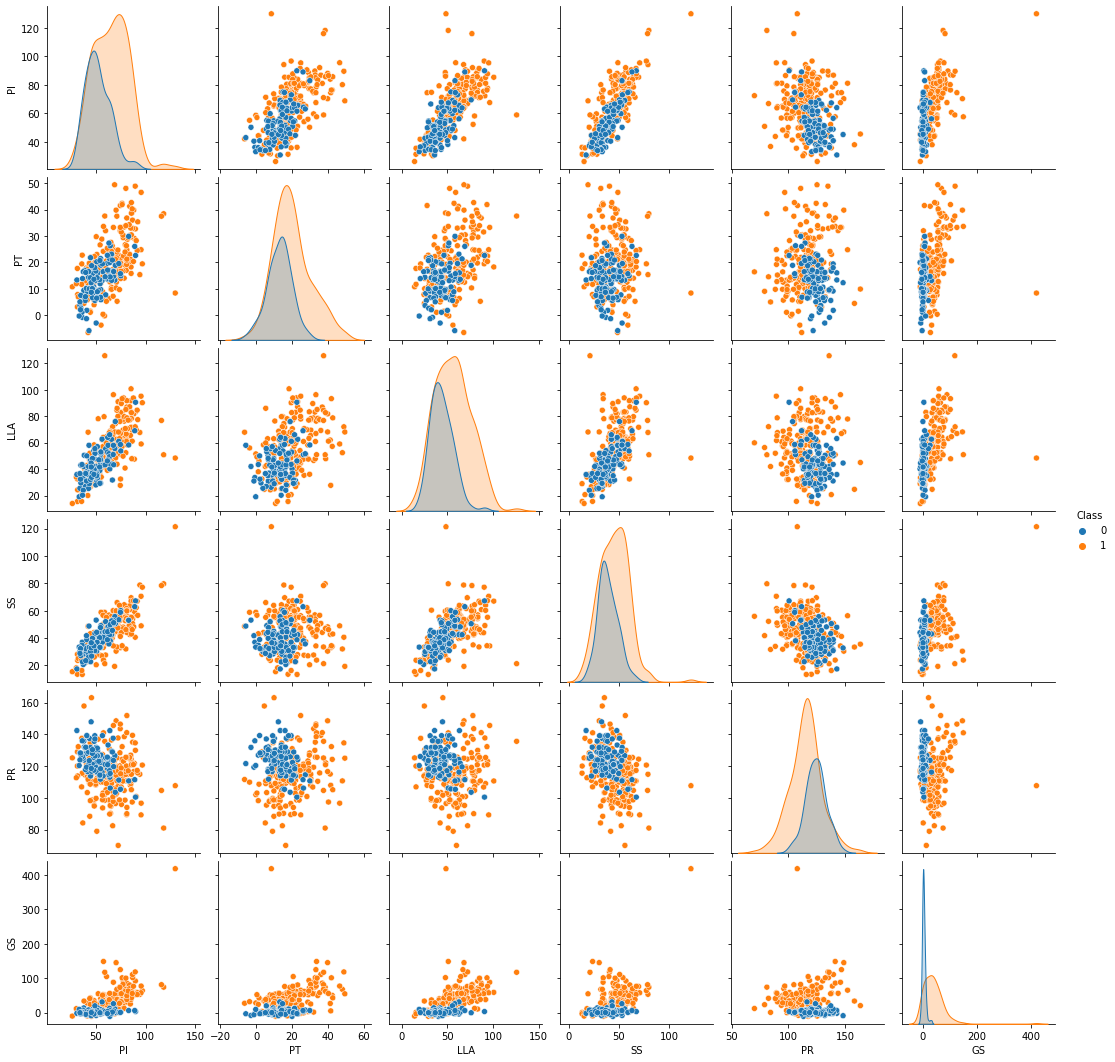

In [8]:
sns.pairplot(df,
    vars=["PI", "PT", "LLA", "SS", "PR", "GS"],
    hue="Class")

plt.show()

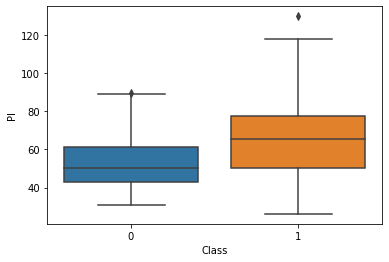

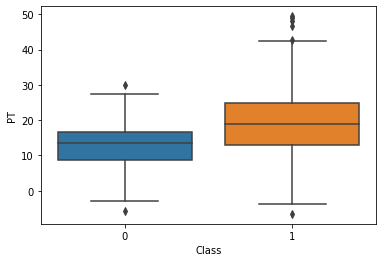

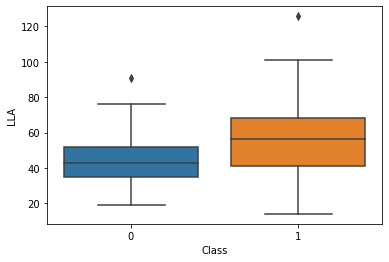

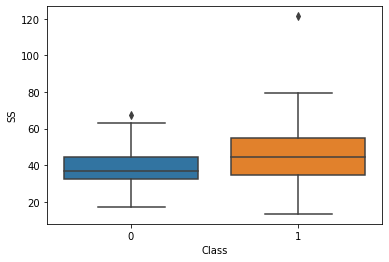

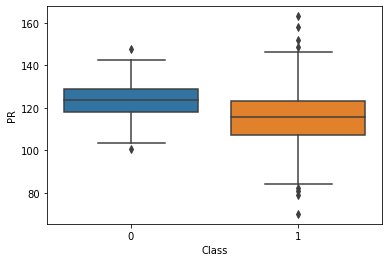

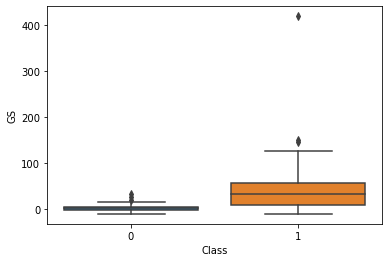

In [9]:
sns.boxplot(data=df, x="Class", y="PI")
plt.show()

sns.boxplot(data=df, x="Class", y="PT")
plt.show()

sns.boxplot(data=df, x="Class", y="LLA")
plt.show()

sns.boxplot(data=df, x="Class", y="SS")
plt.show()

sns.boxplot(data=df, x="Class", y="PR")
plt.show()

sns.boxplot(data=df, x="Class", y="GS")
plt.show()

In [14]:
class0 = df[df["Class"] == 0]
class1 = df[df["Class"] == 1]

train_df = pd.concat([class0.iloc[:70],class1.iloc[:140]])

test_df = pd.concat([class0.iloc[70:],class1.iloc[140:]])

In [15]:
X_train = train_df.drop("Class", axis=1)
Y_train = train_df["Class"]

X_test = test_df.drop("Class", axis=1)
Y_test = test_df["Class"]

print(X_train.shape)
print(Y_train.shape)

print(X_test.shape)
print(Y_test.shape)

(210, 6)
(210,)
(100, 6)
(100,)


In [90]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, f1_score

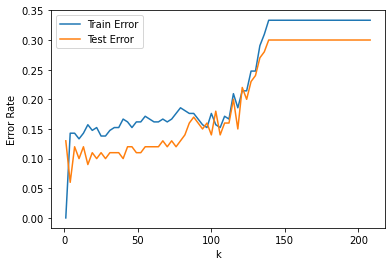

In [91]:
train_errors = []
test_errors = []

for k in range(208, 0, -3):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    Y_trainout = knn.predict(X_train)
    Y_testout = knn.predict(X_test)
    train_error = 1 - accuracy_score(Y_train, Y_trainout)
    test_error = 1 - accuracy_score(Y_test, Y_testout)
    train_errors.append(train_error)
    test_errors.append(test_error)
    
    
    
    
    
plt.plot(range(208, 0, -3), train_errors, label="Train Error")
plt.plot(range(208, 0, -3), test_errors, label="Test Error")
plt.xlabel("k")
plt.ylabel("Error Rate")
plt.legend()
plt.show()


In [92]:
k_values = list(range(208, 0, -3))

min_error = min(test_errors)

index = test_errors.index(min_error)

k_star = k_values[index]
k_manhattan = k_star
best_error_manhattan = min_error

print("Best k =", k_star)
print("Minimum Test Error =", min_error)

Best k = 4
Minimum Test Error = 0.06000000000000005


In [93]:
knn = KNeighborsClassifier(n_neighbors=k_star)

knn.fit(X_train, Y_train)

Y_testout = knn.predict(X_test)

cm = confusion_matrix(Y_test, Y_testout)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[25  5]
 [ 1 69]]


In [94]:
TN, FP, FN, TP = cm.ravel()

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
precision = TP / (TP + FP)

F1 = 2 * precision * TPR / (precision + TPR)

print("TPR =", TPR)
print("TNR =", TNR)
print("Precision =", precision)
print("F1 Score =", F1)

TPR = 0.9857142857142858
TNR = 0.8333333333333334
Precision = 0.9324324324324325
F1 Score = 0.9583333333333333


In [95]:
best_error = []


for N in range(10, 211, 10):

    n0 = N // 3
    n1 = N - n0

    train_df = pd.concat([class0.iloc[:n0],class1.iloc[:n1]])
    test_df = pd.concat([class0.iloc[n0:],class1.iloc[n1:]])

    X_train = train_df.drop("Class", axis=1)
    Y_train = train_df["Class"]
    X_test = test_df.drop("Class", axis=1)
    Y_test = test_df["Class"]
    test_errors = []


    for k in range(1, N, 5):

        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, Y_train)
        Y_testout = knn.predict(X_test)
        test_error = 1 - accuracy_score(Y_test, Y_testout)
        test_errors.append(test_error)

   

    best_error.append(min(test_errors))

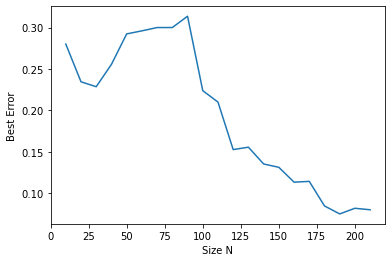

In [96]:
plt.plot(range(10, 211, 10), best_test_errors)

plt.xlabel("Size N")
plt.ylabel("Best Error")

plt.show()

In [97]:
class0 = df[df["Class"] == 0]
class1 = df[df["Class"] == 1]

train_df = pd.concat([class0.iloc[:70],class1.iloc[:140]])

test_df = pd.concat([class0.iloc[70:],class1.iloc[140:]])

In [98]:
test_errors = []

for k in range(1, 197, 5):

    knn = KNeighborsClassifier(n_neighbors=k,metric="minkowski")

    knn.fit(X_train, Y_train)
    Y_testout = knn.predict(X_test)
    test_error = 1 - accuracy_score(Y_test, Y_testout)
    test_errors.append(test_error)

In [99]:
k_values = list(range(1, 197, 5))

best_error = min(test_errors)
index = test_errors.index(best_error)
k_star = k_values[index]


k_minkowski = k_star
best_error_minkowski = best_error

print(k_star)
print(best_error)

6
0.07999999999999996


In [100]:
best_p = None
best_error = 1

for exponent in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]:

    p = 10**exponent

    knn = KNeighborsClassifier(
        n_neighbors=k_star,
        metric="minkowski",
        p=p
    )

    knn.fit(X_train, Y_train)

    Y_testout = knn.predict(X_test)

    error = 1 - accuracy_score(Y_test, Y_testout)

    if error < best_error:
        best_error = error
        best_p = p

print(best_p)
print(best_error)

3.9810717055349722
0.06000000000000005


In [101]:
import math

print(math.log10(best_p))

0.6


In [102]:
test_errors = []

for k in range(1, 197, 5):

    knn = KNeighborsClassifier(n_neighbors=k,metric="chebyshev",p=1)

    knn.fit(X_train, Y_train)
    Y_testout = knn.predict(X_test)
    test_error = 1 - accuracy_score(Y_test, Y_testout)
    test_errors.append(test_error)
k_values = list(range(1, 197, 5))

best_error = min(test_errors)
index = test_errors.index(best_error)
k_star = k_values[index]


k_chebyshev = k_star
best_error_chebyshev = best_error

print(k_star)
print(best_error)

16
0.07999999999999996


In [103]:
import numpy as np

V = np.cov(X_train.T)
VI = np.linalg.inv(V)

In [104]:
test_errors = []

for k in range(1, 197, 5):

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="mahalanobis",
        metric_params={"VI": VI}
    )

    knn.fit(X_train, Y_train)
    Y_testout = knn.predict(X_test)
    test_error = 1 - accuracy_score(Y_test, Y_testout)
    test_errors.append(test_error)

In [105]:
k_values = list(range(1, 197, 5))

best_error = min(test_errors)
index = test_errors.index(best_error)
k_star = k_values[index]

k_mahalanobis = k_star
best_error_mahalanobis = best_error

print(k_star)
print(best_error)

1
0.17000000000000004


In [106]:
summary = [
    ["Manhattan", k_manhattan, best_error_manhattan],
    ["Minkowski", k_minkowski, best_error_minkowski],
    ["Chebyshev", k_chebyshev, best_error_chebyshev],
    ["Mahalanobis", k_mahalanobis, best_error_mahalanobis]]

result_df = pd.DataFrame(summary,columns=["Distance", "Best k", "Test Error"])

print(result_df)

      Distance  Best k  Test Error
0    Manhattan       4        0.06
1    Minkowski       6        0.08
2    Chebyshev      16        0.08
3  Mahalanobis       1        0.17
